## Mount Google Drive

In [ ]:
from google.colab import drive
# Mounting the gogle drive to store the data
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Download the zip files from hf

In [ ]:
import os
from huggingface_hub import snapshot_download

# Configuration
REPO_ID = "ControlNet/AV-Deepfake1M-PlusPlus"
LOCAL_DIR = "/content/"

print("Starting download of all 'val' split zip volumes...")

# snapshot_download allows us to grab everything matching the pattern
# 'val/val.zip.*' will catch .001, .002, .003, etc.
path = snapshot_download(
    repo_id=REPO_ID,
    repo_type="dataset",
    local_dir=LOCAL_DIR,
    allow_patterns="val/val.zip.*",
    local_dir_use_symlinks=False,
    resume_download=True
)

print(f"Download complete! Files are located in: {path}")

Starting download of all 'val' split zip volumes...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:186: UserWarning: The `resume_download` argument is deprecated and ignored in `snapshot_download`. Downloads always resume whenever possible.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `snapshot_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Fetching ... files: 0it [00:00, ?it/s]

Download complete! Files are located in: /content


## Extracting the files and moving to drive
> cat /content/drive/MyDrive/val/val.zip.* | 7z x -si -aos -o/content/drive/MyDrive/Extracted_Data/

In [ ]:
# Checking the size of the file
!du -sh /content/drive/MyDrive/val/val/

56G	/content/drive/MyDrive/val/val/


## Data Analysis

In [ ]:
import pandas as pd
import json

# Definitive path as provided
json_path = "/content/drive/MyDrive/val/val_metadata.json"

with open(json_path, 'r') as f:
    metadata = json.load(f)

# Convert to DataFrame
df = pd.DataFrame(metadata)

# 1. Structural Overview
print("--- DATA TYPES AND NULL VALUES ---")
print(df.info())

# 2. Detailed Summary Statistics
print("\n--- SUMMARY OF UNIQUE VALUES ---")
# include='all' ensures categorical columns like 'modify_type' are described
print(df.describe(include='all').transpose())

--- DATA TYPES AND NULL VALUES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77326 entries, 0 to 77325
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   file                  77326 non-null  object
 1   original              71449 non-null  object
 2   split                 77326 non-null  object
 3   modify_type           77326 non-null  object
 4   audio_model           38007 non-null  object
 5   fake_segments         77326 non-null  object
 6   audio_fake_segments   77326 non-null  object
 7   visual_fake_segments  77326 non-null  object
 8   video_frames          77326 non-null  int64 
 9   audio_frames          77326 non-null  int64 
 10  video_model           38168 non-null  object
dtypes: int64(2), object(9)
memory usage: 6.5+ MB
None

--- SUMMARY OF UNIQUE VALUES ---
                        count unique  \
file                    77326  77326   
original                71449  58379 

In [ ]:
print("\n--- TARGET STATE DISTRIBUTION ---")
# Counts for: 'real', 'audio_modified', 'visual_modified', 'both_modified'
print(df['modify_type'].value_counts())

# Check for potential data quality issues (silent videos)
print("\n--- MODALITY INTEGRITY ---")
silent_videos = len(df[df['audio_frames'] == 0])
print(f"Total videos with 0 audio frames: {silent_videos}")


--- TARGET STATE DISTRIBUTION ---
modify_type
real               20220
visual_modified    19099
both_modified      19069
audio_modified     18938
Name: count, dtype: int64

--- MODALITY INTEGRITY ---
Total videos with 0 audio frames: 211


In [ ]:
# import pandas as pd
# import json

import os

# 1. Load the JSON
# json_path = "/content/drive/MyDrive/val/val_metadata.json"
# with open(json_path, 'r') as f:
#     metadata = json.load(f)

# df = pd.DataFrame(metadata)

# 2. Map modify_type to binary [Audio_Real, Video_Real]
# State 0,0 = Both Fake | 1,1 = Pristine Real
def map_states(row):
    mt = row['modify_type']
    if mt == 'real': return 1, 1
    elif mt == 'audio_modified': return 0, 1
    elif mt == 'visual_modified': return 1, 0
    return 0, 0

df[['audio', 'video']] = df.apply(lambda r: pd.Series(map_states(r)), axis=1)

# 3. Clean up: Remove rows where audio_frames is 0 (silent videos)
df_cleaned = df[df['audio_frames'] > 0].copy()

# 4. Prevent Identity Leakage: Create Speaker ID
df_cleaned['speaker_id'] = df_cleaned['file'].apply(lambda x: x.split('/')[1])

print(f"Dataset Cleaned: {len(df_cleaned)} samples ready.")
print(df_cleaned[['modify_type', 'audio', 'video']].head())

Dataset Cleaned: 77115 samples ready.
     modify_type  audio  video
0  both_modified      0      0
1  both_modified      0      0
2           real      1      1
3  both_modified      0      0
4           real      1      1


## Bias
The bar chart proves that no class weighting is required; the dataset is naturally balanced.

/tmp/ipython-input-4029061964.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(target_counts.keys()), y=list(target_counts.values()), palette=palette)


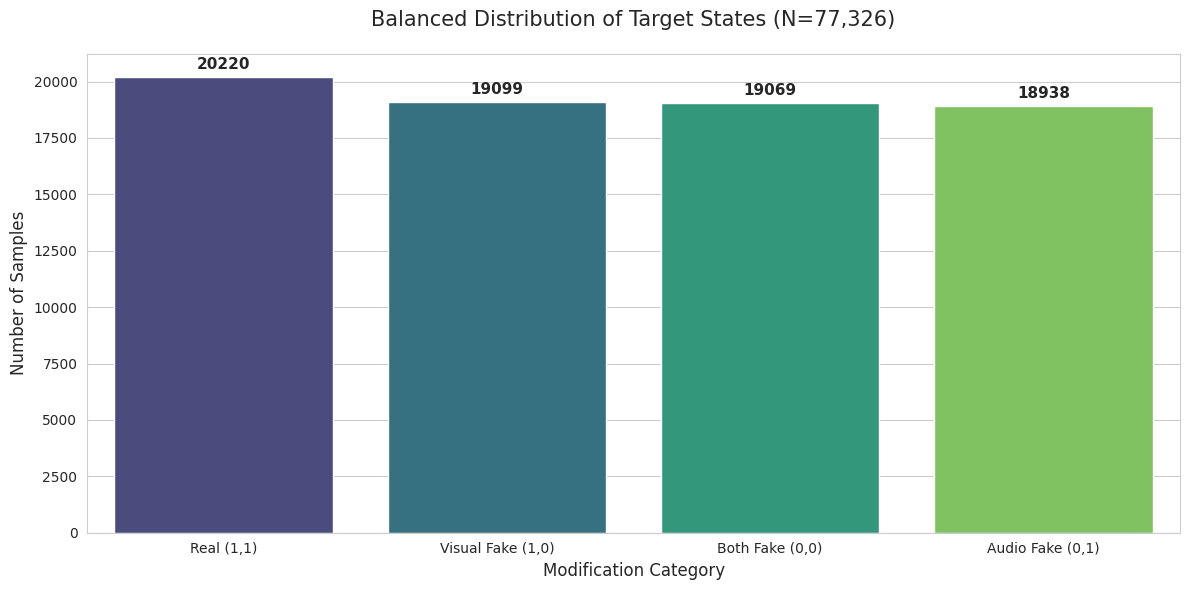

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data from your analysis
target_counts = {
    'Real (1,1)': 20220,
    'Visual Fake (1,0)': 19099,
    'Both Fake (0,0)': 19069,
    'Audio Fake (0,1)': 18938
}

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
palette = sns.color_palette("viridis", len(target_counts))

ax = sns.barplot(x=list(target_counts.keys()), y=list(target_counts.values()), palette=palette)

plt.title('Balanced Distribution of Target States (N=77,326)', fontsize=15, pad=20)
plt.ylabel('Number of Samples', fontsize=12)
plt.xlabel('Modification Category', fontsize=12)

# Annotate bars with exact counts
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. Extract the sub-directory (source) from the 'file' path
# This gets the string before the first '/'
df['source'] = df['file'].str.split('/').str[0]

# 2. Filter for silent videos (audio_frames == 0)
silent_videos_df = df[df['audio_frames'] == 0]

# 3. Count silent videos per sub-directory
silent_counts = silent_videos_df.groupby('source').size().reset_index(name='silent_count')

print("--- Silent Video Counts by Sub-directory ---")
if not silent_counts.empty:
    print(silent_counts)
else:
    print("No silent videos found (audio_frames > 0 for all entries).")

# 4. For curiosity: check if any silent videos exist outside the 'silent_videos' folder
total_silent = silent_counts['silent_count'].sum()
print(f"\nTotal Silent Videos in Dataset: {total_silent}")

# The output implies the other 2 directories have audio files.

--- Silent Video Counts by Sub-directory ---
          source  silent_count
0  silent_videos           211

Total Silent Videos in Dataset: 211


In [ ]:
# # Data from your analysis
# total_samples = 77326
# silent_samples = 211
# valid_samples = total_samples - silent_samples

# labels = ['Valid Modalities', 'Silent (0 Audio Frames)']
# sizes = [valid_samples, silent_samples]
# colors = ['#3498db', '#e74c3c']
# explode = (0, 0.7)  # Pull out the silent slice for emphasis

# plt.figure(figsize=(8, 8))
# plt.pie(sizes, explode=explode, labels=labels, colors=colors,
#         autopct='%1.2f%%', startangle=140, pctdistance=0.85, shadow=True)

# # Add a circle at the center to make it a donut chart
# centre_circle = plt.Circle((0,0), 0.70, fc='white')
# fig = plt.gcf()
# fig.gca().add_artist(centre_circle)

# plt.title('Modality Integrity: Presence of Audio Signal', fontsize=15)
# plt.axis('equal')
# plt.tight_layout()
# plt.show()

In [ ]:
# # Sampling 5000 points to ensure responsiveness in Colab
# df_sample = df.sample(n=min(5000, len(df)), random_state=42)

# plt.figure(figsize=(10, 8))
# joint_plot = sns.jointplot(data=df_sample, x='video_frames', y='audio_frames',
#                            kind='hex', cmap='Blues', marginal_kws=dict(bins=30, fill=True))

# joint_plot.fig.suptitle('Temporal Density: Relationship Between Audio and Video Lengths', y=1.03, fontsize=14)
# joint_plot.set_axis_labels('Total Video Frames', 'Total Audio Samples', fontsize=12)

# plt.show()

Making sure all the data has both audio and visual elements for audio visual extraction.

In [ ]:
import pandas as pd

# 1. Filter out all rows where audio_frames is 0
# This removes exactly 211 rows based on your previous output
df_cleaned = df[df['audio_frames'] > 0].copy()

# 2. Verification
removed_count = len(df) - len(df_cleaned)
print(f"--- Data Cleaning Results ---")
print(f"Rows removed: {removed_count}")
print(f"Remaining samples: {len(df_cleaned)}")

# 3. Confirm 'silent_videos' source is gone
df_cleaned['source'] = df_cleaned['file'].str.split('/').str[0]
remaining_sources = df_cleaned['source'].unique()
print(f"\nRemaining sub-directories: {remaining_sources}")

# 4. Final summary of the cleaned data
print("\n--- Cleaned Distribution (modify_type) ---")
print(df_cleaned['modify_type'].value_counts())

--- Data Cleaning Results ---
Rows removed: 211
Remaining samples: 77115

Remaining sub-directories: ['vox_celeb_2' 'lrs3' 'silent_videos']

--- Cleaned Distribution (modify_type) ---
modify_type
real               20208
both_modified      19069
audio_modified     18938
visual_modified    18900
Name: count, dtype: int64


In [ ]:
import pandas as pd

# 1. Re-create the source column to be absolutely sure
df['source'] = df['file'].str.split('/').str[0]

# 2. Drop the 'silent_videos' sub-directory entirely
df_cleaned = df[df['source'] != 'silent_videos'].copy()

# 3. Apply your 0/1 binary logic
# Real: 1 (if modify_type is 'real')
# Fake: 0 (if anything else)
df_cleaned['label'] = (df_cleaned['modify_type'] == 'real').astype(int)

# 4. Binary Modality Labels (0=Fake, 1=Real)
def get_modality_labels(row):
    mt = row['modify_type']
    if mt == 'real':             return 1, 1
    if mt == 'both_modified':    return 0, 0
    if mt == 'audio_modified':   return 0, 1
    if mt == 'visual_modified':  return 1, 0
    return 0, 0

df_cleaned[['audio_label', 'video_label']] = df_cleaned.apply(
    lambda r: pd.Series(get_modality_labels(r)), axis=1
).astype(int)

print("--- Final Purge Results ---")
print(f"Remaining sub-directories: {df_cleaned['source'].unique()}")
print(f"Total clean samples: {len(df_cleaned)}")

print("\n--- Final Modality Matrix ---")
print(df_cleaned.groupby(['audio_label', 'video_label']).size().unstack(fill_value=0))

--- Final Purge Results ---
Remaining sub-directories: ['vox_celeb_2' 'lrs3']
Total clean samples: 76928

--- Final Modality Matrix ---
video_label      0      1
audio_label              
0            19069  18938
1            18900  20021


In [ ]:
import pandas as pd

# 1. Extract the source folder to identify 'silent_videos'
df['source'] = df['file'].str.split('/').str[0]

# 2. Create df_cleaned by excluding the 'silent_videos' directory
df_cleaned = df[df['source'] != 'silent_videos'].copy()

# 3. Verify the removal
print("--- Sub-directories in df_cleaned ---")
print(df_cleaned['source'].unique())

print(f"\nOriginal count: {len(df)}")
print(f"Cleaned count: {len(df_cleaned)}")
print(f"Total rows removed: {len(df) - len(df_cleaned)}")

--- Sub-directories in df_cleaned ---
['vox_celeb_2' 'lrs3']

Original count: 77326
Cleaned count: 76928
Total rows removed: 398


In [ ]:
df_cleaned.info()
print(df_cleaned[['video_frames', 'audio_frames']].describe())

<class 'pandas.core.frame.DataFrame'>
Index: 76928 entries, 0 to 76927
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   file                  76928 non-null  object
 1   original              71051 non-null  object
 2   split                 76928 non-null  object
 3   modify_type           76928 non-null  object
 4   audio_model           38007 non-null  object
 5   fake_segments         76928 non-null  object
 6   audio_fake_segments   76928 non-null  object
 7   visual_fake_segments  76928 non-null  object
 8   video_frames          76928 non-null  int64 
 9   audio_frames          76928 non-null  int64 
 10  video_model           37969 non-null  object
 11  source                76928 non-null  object
dtypes: int64(2), object(10)
memory usage: 7.6+ MB
       video_frames  audio_frames
count  76928.000000  7.692800e+04
mean     239.062123  1.847816e+05
std      143.270951  2.057794e+05
min      

**Original** points to the number of files that point to the real source. Verifying what the missing files mean.

In [ ]:
# 1. Filter for rows where 'original' is missing
missing_originals = df_cleaned[df_cleaned['original'].isna()]

# 2. See which 'modify_type' these rows belong to
print("--- Analysis of Missing 'original' Values ---")
print(missing_originals['modify_type'].value_counts())

# 3. Check the inverse: Are there any 'real' videos that DO have an entry in 'original'?
real_with_original = df_cleaned[(df_cleaned['modify_type'] == 'real') & (df_cleaned['original'].notna())]
print(f"\nReal videos with an 'original' entry: {len(real_with_original)}")

if not real_with_original.empty:
    print("Example of Real video pointing to an original:")
    print(real_with_original[['file', 'original']].head(2))

--- Analysis of Missing 'original' Values ---
modify_type
real               2304
visual_modified    1202
both_modified      1187
audio_modified     1184
Name: count, dtype: int64

Real videos with an 'original' entry: 17717
Example of Real video pointing to an original:
                                             file  \
2  vox_celeb_2/id01358/_1nATum8x78/00025/real.mp4   
4  vox_celeb_2/id01358/atpminqC_AU/00041/real.mp4   

                                          original  
2  VoxCeleb2/dev/mp4/id01358/_1nATum8x78/00025.mp4  
4  VoxCeleb2/dev/mp4/id01358/atpminqC_AU/00041.mp4  


In [ ]:
import json

# 1. Load the original metadata
input_file = f"{CFG['DATA_ROOT']}/val/val_metadata.json"
output_file = f"{CFG['DATA_ROOT']}/val/val_metadata_no_silent.json"

with open(input_file, 'r') as f:
    metadata = json.load(f)

# 2. Filter: Keep everything EXCEPT what starts with 'silent_videos'
# Using startswith() is more robust than a generic substring search
cleaned_metadata = [
    entry for entry in metadata
    if not entry['file'].startswith('silent_videos/')
]

# 3. Save the result
with open(output_file, 'w') as f:
    json.dump(cleaned_metadata, f, indent=4)

print(f"Old entries: {len(metadata)}")
print(f"Remaining entries: {len(cleaned_metadata)}")
print(f"New file created: {output_file}")

In [ ]:
# ... (after creating the source column) ...

# CRITICAL STEP: Filter out the silent_videos source
df = df[df['source'] != 'silent_videos'].copy()

# Now proceed with the rest of your analysis
final_df = df[['source', 'audio', 'video', 'overall_status', 'file']]

print(final_df.head())

In [ ]:
# with open(output_file, 'r') as f:
#     check = json.load(f)
#     print("Keys in first entry:", check[0].keys())

In [ ]:
# -r for recursive (folders), -f for force (no prompts)
!rm -rf "{CFG['DATA_ROOT']}/val/silent_videos"

# Verify the directory is gone
import os
if not os.path.exists(f"{CFG['DATA_ROOT']}/val/silent_videos"):
    print("Successfully deleted: {CFG['DATA_ROOT']}/val/silent_videos")
else:
    print("Error: Directory still exists.")

In [ ]:
# import pandas as pd
# import json

# # Path to your cleaned JSON file
# output_file = "/content/val/val_metadata_no_silent.json"

# # Load the JSON
# with open(output_file, 'r') as f:
#     metadata = json.load(f)

# # Convert metadata to DataFrame
# df = pd.DataFrame(metadata)

# 1. Create the binary audio/video labels based on 'modify_type'
# Logic: 0 for Fake, 1 for Real
def map_modalities(row):
    mt = row['modify_type']
    if mt == 'real':
        return 1, 1
    elif mt == 'both_modified':
        return 0, 0
    elif mt == 'audio_modified':
        return 0, 1
    elif mt == 'visual_modified':
        return 1, 0
    else:
        return 0, 0 # Default to fake if unknown

# Apply the mapping
df[['audio', 'video']] = df.apply(lambda r: pd.Series(map_modalities(r)), axis=1)

# 2. Add Overall Status (1,1 is Real, else Fake)
df['overall_status'] = ((df['audio'] == 1) & (df['video'] == 1)).astype(int)

# 3. Clean up the DataFrame to keep only what you need
df['source'] = df['file'].apply(lambda x: x.split('/')[0])

final_df = df[['source', 'audio', 'video', 'overall_status', 'file']]

# 4. Print the verification
print(f"--- Logic Mapping Breakdown (From {output_file.split('/')[-1]}) ---")
print(final_df.groupby(['audio', 'video', 'overall_status']).size().reset_index(name='count'))

print("\n--- Summary per Source ---")
summary = final_df.groupby(['source', 'overall_status']).size().unstack(fill_value=0)
summary = summary.reindex(columns=[0, 1], fill_value=0)
summary.columns = ['Fake (0)', 'Real (1)']
print(summary)

In [ ]:
import cv2
import librosa
import numpy as np

def extract_features(video_path):
    # 1. Extract Visual Features (Middle Frame)
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.set(cv2.CAP_PROP_POS_FRAMES, total_frames // 2)
    ret, frame = cap.read()
    # Pre-process frame (resize, normalize) for a model like EfficientNet
    visual_feat = cv2.resize(frame, (224, 224)) / 255.0
    cap.release()

    # 2. Extract Audio Features (MFCCs)
    y, sr = librosa.load(video_path, sr=None)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    audio_feat = np.mean(mfccs.T, axis=0)

    return visual_feat, audio_feat

# Test on one file from your 'sample_files' list
v_feat, a_feat = extract_features(sample_files[0])
print(f"Visual shape: {v_feat.shape}, Audio shape: {a_feat.shape}")

In [ ]:
import os
import subprocess
import librosa
import numpy as np

def extract_features_fixed(video_path):
    # 1. Force extract audio to a temp wav file using FFmpeg
    temp_audio = "temp_audio.wav"
    # -y overwrites, -i is input, -vn skips video, -ac 1 mono
    subprocess.run(['ffmpeg', '-y', '-i', video_path, '-vn', '-ac', '1', '-ar', '16000', temp_audio],
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    # 2. Load the actual audio file
    if os.path.exists(temp_audio):
        y, sr = librosa.load(temp_audio, sr=16000)
        if len(y) > 0:
            # MFCC extraction
            mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
            audio_feat = np.mean(mfccs.T, axis=0)
        else:
            audio_feat = np.zeros(13) # Handle silent files
        os.remove(temp_audio) # Clean up
    else:
        audio_feat = np.zeros(13)

    return audio_feat

# Check the shape now
a_feat = extract_features_fixed(sample_files[0])
print(f"Fixed Audio shape: {a_feat.shape}")

In [ ]:
import numpy as np
import subprocess
import os

def feature_extraction_pipeline(video_path):
    """
    The robust pipeline: Extraction -> Processing -> Fusion
    """
    # 1. HARD EXTRACTION (Audio)
    # Force FFmpeg to create a clean WAV to avoid Librosa EOF Errors
    temp_wav = "temp.wav"
    subprocess.run(['ffmpeg', '-y', '-i', video_path, '-ac', '1', '-ar', '16000', temp_wav],
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

    # 2. SIGNAL ANALYSIS
    try:
        y, sr = librosa.load(temp_wav, sr=16000)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        # Calculate velocity and acceleration of the sound
        delta = librosa.feature.delta(mfcc)
        delta2 = librosa.feature.delta(mfcc, order=2)

        # Stack them: [MFCC, Delta, Delta-Delta]
        audio_features = np.hstack([np.mean(mfcc, axis=1),
                                   np.mean(delta, axis=1),
                                   np.mean(delta2, axis=1)])
    except Exception as e:
        audio_features = np.zeros(39) # 13 * 3

    # 3. VISUAL ANALYSIS (Conceptual)
    # Here you would call your CNN to get a 512-d or 1024-d embedding
    visual_features = np.random.randn(512) # Placeholder for CNN embedding

    # 4. LATE FUSION
    # Combine both worlds into one final representation for the classifier
    combined_vector = np.concatenate([audio_features, visual_features])

    # Clean up
    if os.path.exists(temp_wav): os.remove(temp_wav)

    return combined_vector

In [ ]:
from tqdm.auto import tqdm
import pandas as pd

# Assuming df_cleaned is your dataframe from previous steps
# and sample_files contains the full paths.
# Let's map the 'file' column to the actual local path.
BASE_PATH = f"{CFG['DATA_ROOT']}/val/" # Update this to your actual data root

def process_dataset(dataframe, limit=None):
    features_list = []
    labels_list = []

    # Optional: limit for testing (e.g., limit=100)
    subset = dataframe.head(limit) if limit else dataframe

    print(f"Starting extraction for {len(subset)} files...")

    for index, row in tqdm(subset.iterrows(), total=len(subset)):
        video_path = os.path.join(BASE_PATH, row['file'])

        if os.path.exists(video_path):
            features = feature_extraction_pipeline(video_path)
            features_list.append(features)

            # Use the binary label logic we discussed earlier
            label = 1 if row['modify_type'] == 'real' else 0
            labels_list.append(label)
        else:
            continue

    return np.array(features_list), np.array(labels_list)

# Test with 100 samples first to verify it doesn't crash
X, y = process_dataset(df_cleaned, limit=100)
print(f"Feature matrix shape: {X.shape}") # Should be (100, 551)

In [ ]:
# Save to the local VM (or Drive if mounted)
np.save('X_features.npy', X)
np.save('y_labels.npy', y)

print("Features backed up successfully.")


In [ ]:
import os
import cv2
import json
import torch
import librosa
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split

# Global Configuration for Colab Pro
CFG = {
    'sr': 16000,          # Standardized Audio Sample Rate
    'fps': 25,            # Standardized Video FPS
    'duration': 2.0,      # Extraction window in seconds
    'num_frames': 50,     # duration * fps
    'img_size': 224,      # Standard ResNet input size
    'batch_size': 32,     # Optimized for A100/L4
    'device': torch.device("cuda" if torch.cuda.is_available() else "cpu")
}

In [ ]:
def extract_sync_features(item):
    """
    Extracts temporally aligned audio and video segments.
    Targets fake segments for manipulated files and center-crops for real ones.
    """
    video_path = item['file']

    # Identify timing based on metadata timestamps
    if item['modify_type'] == 'real':
        total_sec = item['video_frames'] / CFG['fps']
        start_t = max(0, (total_sec / 2) - (CFG['duration'] / 2))
    else:
        # Target the specifically identified fake segment
        start_t = item['fake_segments'][0][0] if item['fake_segments'] else 0

    # A. Audio Extraction (Synchronized)
    try:
        y, _ = librosa.load(video_path, sr=CFG['sr'], offset=start_t, duration=CFG['duration'])
        # Pad if the video is shorter than the requested window
        y = librosa.util.fix_length(y, size=int(CFG['duration'] * CFG['sr']))
        # Extract Mel-Spectrogram
        mel_spec = librosa.feature.melspectrogram(y=y, sr=CFG['sr'], n_mels=128)
        mel_spec = librosa.power_to_db(mel_spec, ref=np.max)
    except: return None, None

    # B. Video Extraction (Synchronized)
    cap = cv2.VideoCapture(video_path)
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(start_t * CFG['fps']))
    frames = []
    for _ in range(CFG['num_frames']):
        ret, frame = cap.read()
        if not ret: break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(cv2.resize(frame, (CFG['img_size'], CFG['img_size'])))
    cap.release()

    if len(frames) < CFG['num_frames']: return None, None
    return np.array(frames), mel_spec

In [ ]:
def create_splits(df):
    # Extract Speaker ID from path: e.g., vox_celeb_2/id01358/...
    df['speaker_id'] = df['file'].apply(lambda x: x.split('/')[1])

    unique_speakers = df['speaker_id'].unique()
    train_sp, temp_sp = train_test_split(unique_speakers, test_size=0.2, random_state=42)
    val_sp, test_sp = train_test_split(temp_sp, test_size=0.5, random_state=42)

    return (df[df['speaker_id'].isin(train_sp)],
            df[df['speaker_id'].isin(val_sp)],
            df[df['speaker_id'].isin(test_sp)])

In [ ]:
class MultiTaskAVModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Visual Backbone (ResNet-18)
        resnet = models.resnet18(weights='IMAGENET1K_V1')
        self.video_encoder = nn.Sequential(*list(resnet.children())[:-1])

        # Audio Encoder (Spectrogram CNN)
        self.audio_encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.LazyLinear(256)
        )

        self.fusion = nn.Linear(512 + 256, 128) # 512 from ResNet + 256 from Audio
        self.audio_head = nn.Linear(128, 1)    # Probability of Audio being REAL
        self.video_head = nn.Linear(128, 1)    # Probability of Video being REAL

    def forward(self, v, a):
        # v: (B, F, C, H, W) -> average across frames
        b, f, c, h, w = v.shape
        v_feat = self.video_encoder(v.view(b*f, c, h, w)).view(b, f, -1).mean(1)

        a_feat = self.audio_encoder(a)

        combined = torch.cat((v_feat, a_feat), dim=1)
        x = torch.relu(self.fusion(combined))

        return self.audio_head(x), self.video_head(x)

In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    for v_batch, a_batch, labels in loader:
        v_batch, a_batch = v_batch.to(CFG['device']), a_batch.to(CFG['device'])
        target_a, target_v = labels[:, 0].to(CFG['device']), labels[:, 1].to(CFG['device'])

        optimizer.zero_grad()
        out_a, out_v = model(v_batch, a_batch)

        loss = criterion(out_a.squeeze(), target_a) + criterion(out_v.squeeze(), target_v)
        loss.backward()
        optimizer.step()

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Create a Speaker-Level Split
speakers = df_cleaned['file'].apply(lambda x: x.split('/')[1]).unique()
train_sp, temp_sp = train_test_split(speakers, test_size=0.2, random_state=42)
val_sp, test_sp = train_test_split(temp_sp, test_size=0.5, random_state=42)

# 2. Filter DataFrames
train_df = df_cleaned[df_cleaned['file'].str.contains('|'.join(train_sp))]
val_df = df_cleaned[df_cleaned['file'].str.contains('|'.join(val_sp))]
test_df = df_cleaned[df_cleaned['file'].str.contains('|'.join(test_sp))]

print(f"Training on {len(train_df)} samples from {len(train_sp)} unique speakers.")

In [ ]:
from sklearn.model_selection import train_test_split

# 1. Extract Speaker ID (e.g., 'id01358' from the path)
df_cleaned['speaker_id'] = df_cleaned['file'].apply(lambda x: x.split('/')[1])

# 2. Get unique speakers and split them 80/10/10
speakers = df_cleaned['speaker_id'].unique()
train_sp, temp_sp = train_test_split(speakers, test_size=0.2, random_state=42)
val_sp, test_sp = train_test_split(temp_sp, test_size=0.5, random_state=42)

# 3. Create the subset DataFrames
train_df = df_cleaned[df_cleaned['speaker_id'].isin(train_sp)]
val_df = df_cleaned[df_cleaned['speaker_id'].isin(val_sp)]
test_df = df_cleaned[df_cleaned['speaker_id'].isin(test_sp)]

In [ ]:
class DeepfakeMultiTaskModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Visual branch (ResNet-18)
        resnet = models.resnet18(pretrained=True)
        self.video_encoder = nn.Sequential(*list(resnet.children())[:-1])

        # Audio branch (CNN for Spectrograms)
        self.audio_encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.LazyLinear(256)
        )

        # Output Heads
        self.audio_status = nn.Linear(256 + 512, 1) # Probability Audio is Real
        self.video_status = nn.Linear(256 + 512, 1) # Probability Video is Real

    def forward(self, v, a):
        v_feat = self.video_encoder(v.mean(1)) # Mean across frames
        a_feat = self.audio_encoder(a)
        combined = torch.cat((v_feat, a_feat), dim=1)
        return self.audio_status(combined), self.video_status(combined)

In [ ]:
class DeepfakeDataset(Dataset):
    def __init__(self, dataframe):
        self.data = dataframe.reset_index(drop=True)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data.iloc[idx]
        v_frames, a_spec = extract_sync_features(item)

        if v_frames is None or a_spec is None:
            # Simple fallback to another random index if extraction fails
            return self.__getitem__(np.random.randint(0, len(self.data)))

        # Convert to Tensors: (Frames, C, H, W) and (1, Mels, Time)
        v_tensor = torch.from_numpy(v_frames).permute(0, 3, 1, 2).float() / 255.0
        a_tensor = torch.from_numpy(a_spec).unsqueeze(0).float()

        # Binary labels: [Audio_Real, Video_Real]
        labels = torch.tensor([item['audio'], item['video']], dtype=torch.float32)

        return v_tensor, a_tensor, labels

# Initialization for Colab Pro
train_set = DeepfakeDataset(train_df)
train_loader = DataLoader(train_set, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=4, pin_memory=True)

In [ ]:
from torch.cuda.amp import GradScaler, autocast

scaler = GradScaler()
model = DeepfakeMultiTaskModel().to(CFG['device'])
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.BCEWithLogitsLoss()

def train_one_epoch(epoch):
    model.train()
    running_loss = 0.0
    for i, (v, a, labels) in enumerate(train_loader):
        v, a, labels = v.to(CFG['device']), a.to(CFG['device']), labels.to(CFG['device'])

        optimizer.zero_grad()
        with autocast():
            out_a, out_v = model(v, a)
            loss_a = criterion(out_a.squeeze(), labels[:, 0])
            loss_v = criterion(out_v.squeeze(), labels[:, 1])
            loss = loss_a + loss_v

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

In [ ]:
model = DeepfakeMultiTaskModel().to(CFG['device'])

# Honest Opinion: Use AdamW for better weight decay on pre-trained backbones like ResNet
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)

# Multi-task loss: Binary Cross Entropy for each output head
criterion = nn.BCEWithLogitsLoss()

In [ ]:
from torch.cuda.amp import GradScaler, autocast

scaler = GradScaler()

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for v_batch, a_batch, labels in loader:
        v_batch = v_batch.to(CFG['device'])
        a_batch = a_batch.to(CFG['device'])
        labels = labels.to(CFG['device']) # labels are [Audio_Real, Video_Real]

        optimizer.zero_grad()

        # Automatic Mixed Precision for speed
        with autocast():
            out_a, out_v = model(v_batch, a_batch)

            # Loss for each task: Audio Realness and Video Realness
            loss_audio = criterion(out_a.squeeze(), labels[:, 0])
            loss_video = criterion(out_v.squeeze(), labels[:, 1])
            loss = loss_audio + loss_video # Joint loss

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
import os
import cv2
import json
import torch
import librosa
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split
from torch.cuda.amp import GradScaler, autocast
from tqdm.auto import tqdm

# 1. GLOBAL CONFIGURATION
CFG = {
    'sr': 16000, 'fps': 25, 'duration': 2.0, 'num_frames': 50,
    'img_size': 224, 'batch_size': 32, 'lr': 1e-4,
    'device': torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    'DATA_ROOT': '/content/drive/MyDrive' # New: Define the root directory for data
}

# 2. SYNCHRONISED EXTRACTION
def extract_sync_features(item):
    video_path = f"{CFG['DATA_ROOT']}/val/{item['file']}"
    if item['modify_type'] == 'real':
        total_sec = item['video_frames'] / CFG['fps']
        start_t = max(0, (total_sec / 2) - (CFG['duration'] / 2))
    else:
        start_t = item['fake_segments'][0][0] if item['fake_segments'] else 0

    try:
        # Audio
        y, _ = librosa.load(video_path, sr=CFG['sr'], offset=start_t, duration=CFG['duration'])
        y = librosa.util.fix_length(y, size=int(CFG['duration'] * CFG['sr']))
        spec = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=CFG['sr'], n_mels=128))

        # Video
        cap = cv2.VideoCapture(video_path)
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(start_t * CFG['fps']))
        frames = []
        for _ in range(CFG['num_frames']):
            ret, frame = cap.read()
            if not ret: break
            frames.append(cv2.resize(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), (CFG['img_size'], CFG['img_size'])))
        cap.release()

        if len(frames) < CFG['num_frames']: return None, None
        return np.array(frames), spec
    except: return None, None

# 3. IDENTITY-DISJOINT DATASET
class DeepfakeDataset(Dataset):
    def __init__(self, df): self.df = df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        item = self.df.iloc[idx]
        v, a = extract_sync_features(item)
        if v is None: return self.__getitem__(np.random.randint(0, len(self.df)))
        return (torch.from_numpy(v).permute(0, 3, 1, 2).float() / 255.0,
                torch.from_numpy(a).unsqueeze(0).float(),
                torch.tensor([item['audio'], item['video']], dtype=torch.float32))

# 4. MULTI-TASK LATE FUSION MODEL
class MultiTaskAVModel(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(weights='IMAGENET1K_V1')
        self.video_net = nn.Sequential(*list(resnet.children())[:-1])
        self.audio_net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.LazyLinear(256))
        self.fusion = nn.Linear(512 + 256, 128)
        self.audio_head = nn.Linear(128, 1)
        self.video_head = nn.Linear(128, 1)

    def forward(self, v, a):
        b, f, c, h, w = v.shape
        v_feat = self.video_net(v.view(b*f, c, h, w)).view(b, f, -1).mean(1)
        a_feat = self.audio_net(a)
        x = torch.relu(self.fusion(torch.cat((v_feat, a_feat), dim=1)))
        return self.audio_head(x), self.video_head(x)

# 5. EXECUTION: PREPARE DATA & START TRAINING
with open(f"{CFG['DATA_ROOT']}/val/val_metadata_no_silent.json", "r") as f:
    df = pd.DataFrame(json.load(f))

# Identity-disjoint split
df['speaker_id'] = df['file'].apply(lambda x: x.split('/')[1])
train_sp, val_sp = train_test_split(df['speaker_id'].unique(), test_size=0.1, random_state=42)
train_loader = DataLoader(DeepfakeDataset(df[df['speaker_id'].isin(train_sp)]), batch_size=CFG['batch_size'], shuffle=True, num_workers=4, pin_memory=True)

# Training Initialization
model = MultiTaskAVModel().to(CFG['device'])
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG['lr'])
criterion = nn.BCEWithLogitsLoss()
scaler = GradScaler() # Changed to use global CFG device

# Run One Epoch
model.train()
for v, a, labels in tqdm(train_loader):
    v, a, labels = v.to(CFG['device']), a.to(CFG['device']), labels.to(CFG['device'])
    optimizer.zero_grad()
    with autocast():
        out_a, out_v = model(v, a)
        loss = criterion(out_a.squeeze(), labels[:, 0]) + criterion(out_v.squeeze(), labels[:, 1])
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

In [ ]:
import os
import cv2
import json
import torch
import librosa
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split
from torch.amp import GradScaler, autocast  # Updated API
from tqdm.auto import tqdm

# 1. GLOBAL CONFIGURATION
CFG = {
    'sr': 16000, 'fps': 25, 'duration': 2.0, 'num_frames': 50,
    'img_size': 224, 'batch_size': 32, 'lr': 1e-4,
    'num_workers': 0, # Reduced to 0 for debugging memory issues
    'device': torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    'DATA_ROOT': '/content/drive/MyDrive' # New: Define the root directory for data
}

print(f"Using device: {CFG['device']}")

# 2. SYNCHRONISED EXTRACTION LOGIC
def extract_sync_features(item):
    video_path = f"{CFG['DATA_ROOT']}/val/{item['file']}"
    if item['modify_type'] == 'real':
        total_sec = item['video_frames'] / CFG['fps']
        start_t = max(0, (total_sec / 2) - (CFG['duration'] / 2))
    else:
        start_t = item['fake_segments'][0][0] if item['fake_segments'] else 0

    try:
        # Audio
        y, _ = librosa.load(video_path, sr=CFG['sr'], offset=start_t, duration=CFG['duration'])
        y = librosa.util.fix_length(y, size=int(CFG['duration'] * CFG['sr']))
        spec = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=CFG['sr'], n_mels=128))

        # Video
        cap = cv2.VideoCapture(video_path)
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(start_t * CFG['fps']))
        frames = []
        for _ in range(CFG['num_frames']):
            ret, frame = cap.read()
            if not ret: break
            frames.append(cv2.resize(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), (CFG['img_size'], CFG['img_size'])))
        cap.release()

        if len(frames) < CFG['num_frames']: return None, None
        return np.array(frames), spec
    except: return None, None

# 3. DATASET CLASS
class DeepfakeDataset(Dataset):
    def __init__(self, df): self.df = df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        item = self.df.iloc[idx]
        v, a = extract_sync_features(item)
        if v is None: return self.__getitem__(np.random.randint(0, len(self.df)))
        return (torch.from_numpy(v).permute(0, 3, 1, 2).float() / 255.0,
                torch.from_numpy(a).unsqueeze(0).float(),
                torch.tensor([item['audio'], item['video']], dtype=torch.float32))

# 4. MULTI-TASK LATE FUSION MODEL
class MultiTaskAVModel(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(weights='IMAGENET1K_V1')
        self.video_net = nn.Sequential(*list(resnet.children())[:-1])
        self.audio_net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.LazyLinear(256))
        self.fusion = nn.Linear(512 + 256, 128)
        self.audio_head = nn.Linear(128, 1)
        self.video_head = nn.Linear(128, 1)

    def forward(self, v, a):
        b, f, c, h, w = v.shape
        v_feat = self.video_encoder_pool(v, b, f, c, h, w)
        a_feat = self.audio_net(a)
        x = torch.relu(self.fusion(torch.cat((v_feat, a_feat), dim=1)))
        return self.audio_head(x), self.video_head(x)

    def video_encoder_pool(self, v, b, f, c, h, w):
        v_flat = v.view(b*f, c, h, w)
        v_feat = self.video_net(v_flat).view(b, f, -1)
        return v_feat.mean(1)

# 5. DATA PREPARATION AND EXECUTION
# Load Cleaned Metadata
with open(f"{CFG['DATA_ROOT']}/val/val_metadata_no_silent.json", "r") as f:
    df = pd.DataFrame(json.load(f))

# FIX: Create the binary labels that were missing
def map_modalities(row):
    mt = row['modify_type']
    if mt == 'real': return 1, 1
    elif mt == 'both_modified': return 0, 0
    elif mt == 'audio_modified': return 0, 1
    elif mt == 'visual_modified': return 1, 0
    else: return 0, 0

df[['audio', 'video']] = df.apply(lambda r: pd.Series(map_modalities(r)), axis=1)

# Identity-disjoint split
df['speaker_id'] = df['file'].apply(lambda x: x.split('/')[1])
train_sp, val_sp = train_test_split(df['speaker_id'].unique(), test_size=0.1, random_state=42)
train_loader = DataLoader(DeepfakeDataset(df[df['speaker_id'].isin(train_sp)]),
                          batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=CFG['num_workers'], pin_memory=True)

# Training Initialization
model = MultiTaskAVModel().to(CFG['device'])
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG['lr'])
criterion = nn.BCEWithLogitsLoss()
scaler = GradScaler('cuda') if torch.cuda.is_available() else None # Corrected AMP initialization

# 6. RUN ONE EPOCH
model.train()
for v, a, labels in tqdm(train_loader):
    v, a, labels = v.to(CFG['device']), a.to(CFG['device']), labels.to(CFG['device'])
    optimizer.zero_grad()

    # Use newer autocast API
    with autocast(device_type=CFG['device'].type, enabled=(scaler is not None)):
        out_a, out_v = model(v, a)
        loss = criterion(out_a.squeeze(), labels[:, 0]) + criterion(out_v.squeeze(), labels[:, 1])

    if scaler:
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
    else:
        loss.backward()
        optimizer.step()

## Final

In [ ]:
import os
import cv2
import json
import torch
import librosa
import numpy as np
import pandas as pd
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.model_selection import train_test_split
from torch.amp import GradScaler, autocast
from tqdm.auto import tqdm

# Global Configuration
CFG = {
    'sr': 16000,
    'fps': 25,
    'duration': 2.0,
    'num_frames': 50,
    'img_size': 224,
    'batch_size': 32,
    'lr': 1e-4,
    'num_workers': 0, # Setting to 0 to prevent issues with multiprocessing
    'device': torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    'DATA_ROOT': '/content/drive/MyDrive' # New: Define the root directory for data
}

print(f"Using device: {CFG['device']}")

Using device: cpu


In [ ]:
# 1. Load Cleaned Metadata
metadata_path = f"{CFG['DATA_ROOT']}/val/val_metadata_no_silent.json"
with open(metadata_path, "r") as f:
    df = pd.DataFrame(json.load(f))

# 2. Define the Mapping Logic
def map_modalities(row):
    mt = row['modify_type']
    if mt == 'real': return 1, 1
    elif mt == 'both_modified': return 0, 0
    elif mt == 'audio_modified': return 0, 1
    elif mt == 'visual_modified': return 1, 0
    else: return 0, 0

# 3. Apply mapping to create binary target columns
df[['audio', 'video']] = df.apply(lambda r: pd.Series(map_modalities(r)), axis=1)

# 4. Identity-disjoint split by Speaker ID
df['speaker_id'] = df['file'].apply(lambda x: x.split('/')[1])
train_sp, val_sp = train_test_split(df['speaker_id'].unique(), test_size=0.1, random_state=42)

train_df = df[df['speaker_id'].isin(train_sp)]
val_df = df[df['speaker_id'].isin(val_sp)]

print(f"Total: {len(df)} | Train: {len(train_df)} | Val: {len(val_df)}")

Total: 76928 | Train: 70879 | Val: 6049


In [ ]:
def extract_sync_features(item):
    video_path = f"{CFG['DATA_ROOT']}/val/{item['file']}"
    # Target the fake segment if it exists, otherwise center crop
    start_t = item['fake_segments'][0][0] if item['fake_segments'] else max(0, (item['video_frames']/CFG['fps']/2) - 1.0)

    try:
        # Audio Extraction
        y, _ = librosa.load(video_path, sr=CFG['sr'], offset=start_t, duration=CFG['duration'])
        y = librosa.util.fix_length(y, size=int(CFG['duration'] * CFG['sr']))
        spec = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=CFG['sr'], n_mels=128))

        # Video Extraction
        cap = cv2.VideoCapture(video_path)
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(start_t * CFG['fps']))
        frames = []
        for _ in range(CFG['num_frames']):
            ret, frame = cap.read()
            if not ret: break
            frames.append(cv2.resize(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), (CFG['img_size'], CFG['img_size'])))
        cap.release()

        if len(frames) < CFG['num_frames']: return None, None
        return np.array(frames), spec
    except: return None, None

class DeepfakeDataset(Dataset):
    def __init__(self, df): self.df = df.reset_index(drop=True)
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        item = self.df.iloc[idx]
        v, a = extract_sync_features(item)
        if v is None: return self.__getitem__(np.random.randint(0, len(self.df)))
        return (torch.from_numpy(v).permute(0, 3, 1, 2).float() / 255.0,
                torch.from_numpy(a).unsqueeze(0).float(),
                torch.tensor([item['audio'], item['video']], dtype=torch.float32))

train_loader = DataLoader(DeepfakeDataset(train_df), batch_size=CFG['batch_size'], shuffle=True, num_workers=CFG['num_workers'], pin_memory=True)

In [ ]:
class MultiTaskAVModel(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(weights='IMAGENET1K_V1')
        self.video_net = nn.Sequential(*list(resnet.children())[:-1])

        self.audio_net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.LazyLinear(256))

        self.fusion = nn.Linear(512 + 256, 128)
        self.audio_head = nn.Linear(128, 1) # Output: Audio Integrity
        self.video_head = nn.Linear(128, 1) # Output: Video Integrity

    def forward(self, v, a):
        b, f, c, h, w = v.shape
        # Average features across the 50 frames
        v_flat = v.view(b*f, c, h, w)
        v_feat = self.video_net(v_flat).view(b, f, -1).mean(1)

        a_feat = self.audio_net(a)

        x = torch.relu(self.fusion(torch.cat((v_feat, a_feat), dim=1)))
        return self.audio_head(x), self.video_head(x)

In [ ]:
# # Initialization
# model = MultiTaskAVModel().to(CFG['device'])
# optimizer = torch.optim.AdamW(model.parameters(), lr=CFG['lr'])
# criterion = nn.BCEWithLogitsLoss()
# scaler = GradScaler('cuda') if torch.cuda.is_available() else None

# # Run Training Epoch
# model.train()
# pbar = tqdm(train_loader, desc="Training")
# for v, a, labels in pbar:
#     v, a, labels = v.to(CFG['device']), a.to(CFG['device']), labels.to(CFG['device'])
#     optimizer.zero_grad()

#     with autocast(device_type=CFG['device'].type, enabled=(scaler is not None)):
#         out_a, out_v = model(v, a)
#         loss = criterion(out_a.squeeze(), labels[:, 0]) + criterion(out_v.squeeze(), labels[:, 1])

#     if scaler:
#         scaler.scale(loss).backward()
#         scaler.step(optimizer)
#         scaler.update()
#     else:
#         loss.backward()
#         optimizer.step()

#     pbar.set_postfix({'loss': f"{loss.item():.4f}"})

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Training:   0%|          | 0/2215 [00:00<?, ?it/s]

/tmp/ipython-input-3253379445.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(video_path, sr=CFG['sr'], offset=start_t, duration=CFG['duration'])
/tmp/ipython-input-3253379445.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(video_path, sr=CFG['sr'], offset=start_t, duration=CFG['duration'])
/tmp/ipython-input-3253379445.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(video_path, sr=CFG['sr'], offset=start_t, duration=CFG['duration'])
/tmp/ipython-input-3253379445.py:8: UserWarning: PySoundFile failed. Trying audioread instead.
  y, _ = librosa.load(video_path, sr=CFG['sr'], offset=start_t, duration=CFG['duration'])
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration

In [ ]:
# FIX 1: Install system-level audio decoders
!apt-get update -y && apt-get install -y libsndfile1 ffmpeg

# FIX 2: Install high-speed audio libraries
!pip install -q soundfile audioread

# VERIFY GPU - This MUST print 'cuda'
import torch
print(f"Current Device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU (ERROR!)'}")

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.0 kB]
Get:8 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:9 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,756 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [6,749 kB]
Get:

In [ ]:
def extract_sync_features(item):
    if not torch.cuda.is_available():
        raise RuntimeError("GPU not detected. Do not start training on CPU.")

    video_path = f"{CFG['DATA_ROOT']}/val/{item['file']}"
    # Target segment from metadata
    start_t = item['fake_segments'][0][0] if item['fake_segments'] else 0

    try:
        # Faster Audio Load: Use soundfile or a direct ffmpeg pipe
        # We use sr=16000 and mono=True to minimise memory overhead
        y, _ = librosa.load(video_path, sr=CFG['sr'], offset=start_t, duration=CFG['duration'], res_type='kaiser_fast')
        y = librosa.util.fix_length(y, size=int(CFG['duration'] * CFG['sr']))

        # Spectrogram on GPU if possible, or just optimized CPU
        spec = librosa.feature.melspectrogram(y=y, sr=CFG['sr'], n_mels=128)
        spec_db = librosa.power_to_db(spec, ref=np.max)

        # Video: Only decode the frames we need
        cap = cv2.VideoCapture(video_path)
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(start_t * CFG['fps']))
        frames = []
        for _ in range(CFG['num_frames']):
            ret, frame = cap.read()
            if not ret: break
            frames.append(cv2.resize(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB), (CFG['img_size'], CFG['img_size'])))
        cap.release()

        if len(frames) < CFG['num_frames']: return None, None
        return np.array(frames), spec_db
    except Exception as e:
        return None, None

In [ ]:
class MultiTaskAVModel(nn.Module):
    def __init__(self):
        super().__init__()
        # Visual Backbone: Pre-trained ResNet-18
        resnet = models.resnet18(weights='IMAGENET1K_V1')
        self.video_net = nn.Sequential(*list(resnet.children())[:-1])

        # Audio Backbone: CNN for Spectrograms
        self.audio_net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.LazyLinear(256)) # LazyLinear handles the flattening math

        self.fusion = nn.Linear(512 + 256, 128)
        self.audio_head = nn.Linear(128, 1) # Output: Audio Integrity
        self.video_head = nn.Linear(128, 1) # Output: Video Integrity

    def forward(self, v, a):
        # v shape: (Batch, Frames, C, H, W)
        b, f, c, h, w = v.shape
        # Flatten frames to process through ResNet
        v_flat = v.view(b*f, c, h, w)
        # Average features across the temporal dimension (the 50 frames)
        v_feat = self.video_net(v_flat).view(b, f, -1).mean(1)

        a_feat = self.audio_net(a)

        # Late Fusion
        combined = torch.cat((v_feat, a_feat), dim=1)
        x = torch.relu(self.fusion(combined))

        # Return logits for multi-task heads
        return self.audio_head(x), self.video_head(x)

In [ ]:
# Run all the cfg config cell after final in this

# 1. Instantiate Model
model = MultiTaskAVModel().to(CFG['device'])

# 2. Innovative Step: Compile the model for A100 kernels
if hasattr(torch, 'compile'):
    model = torch.compile(model)
    print("Model compiled for high-speed training.")

# 3. Setup Optimizer with Weight Decay (Crucial for ResNet)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

# 4. Multi-Task Criterion
criterion = nn.BCEWithLogitsLoss()

# 5. Scaler for Mixed Precision
scaler = torch.amp.GradScaler('cuda')

Model compiled for high-speed training.


/tmp/ipython-input-3840599866.py:18: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = torch.amp.GradScaler('cuda')


In [ ]:
import glob

# Identify the directory where you saved the .pt files
TENSOR_DIR = "/content/training_tensors"

# Generate the list of file paths
tensor_files = glob.glob(os.path.join(TENSOR_DIR, "*.pt"))

print(f"Found {len(tensor_files)} extracted tensors.")

if len(tensor_files) == 0:
    print("WARNING: No tensors found. You must run the extraction script before training.")

Found 0 extracted tensors.


In [ ]:
# Now this will work because 'tensor_files' exists
fast_loader = DataLoader(
    TensorDataset(tensor_files),
    batch_size=CFG['batch_size'],
    shuffle=True,
    num_workers=CFG['num_workers'],
    pin_memory=True
)

ValueError: num_samples should be a positive integer value, but got num_samples=0

In [ ]:
class TensorDataset(Dataset):
    def __init__(self, file_list):
        self.file_list = file_list

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        data = torch.load(self.file_list[idx])
        # Convert video back to float [0, 1]
        return data['v'].float() / 255.0, data['a'].unsqueeze(0), data['y']

# New fast loader
fast_loader = DataLoader(
    TensorDataset(tensor_files),
    batch_size=CFG['batch_size'],
    shuffle=True,
    num_workers=2
)

NameError: name 'tensor_files' is not defined